In [16]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics

from sklearn.decomposition import PCA
from sklearn import datasets
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, ConfusionMatrixDisplay, confusion_matrix, silhouette_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

# 랜덤 포레스트 분류예측

* 여러 개의 결정트리(Decision Tree)를 조합하여 예측 성능을 향상시키는 기법
* “분류 예측”이 주용도이고, 부가적으로 “특성 중요도 확인”에도 많이 사용
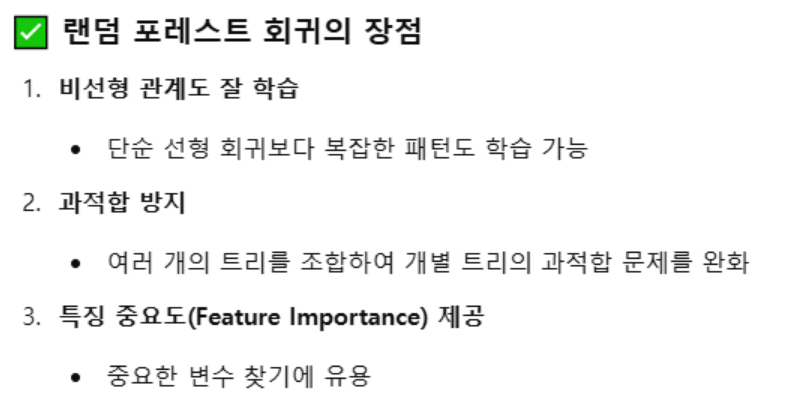

## 1. 데이터 불러오기

In [5]:
from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [6]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

## 2. 학습용 / 테스트용 나누기 (80% / 20%)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## 3. 모델 생성

In [ ]:
model = RandomForestClassifier(random_state=0, n_estimators = 100, n_jobs = -1) 

## n_estimators = 100 : 100개의 결정트리를 사용하여 학습
## n_jobs = -1 : CPU 전부 사용 (속도 향상)

## 4. 학습

In [11]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 5. 예측

In [12]:
y_pred = model.predict(X_test)

## 6. 정확도 확인

In [13]:
acc = accuracy_score(y_test, y_pred)
print("정확도:", acc)

정확도: 1.0


## 7. 새로운 데이터로 분류 예측

In [14]:
# 새로운 데이터 (꽃 길이, 너비 4개 값)
new_data = [[5.0, 3.4, 1.5, 0.2]]

# 예측
pred = model.predict(new_data)  # 꽃 품종의 번호(분류) 예측

print(pred) 
print(iris.target_names[pred])

[0]
['setosa']


In [15]:
new_data = [
    [5.0, 3.4, 1.5, 0.2],
    [6.2, 3.0, 4.8, 1.8]
]

pred = model.predict(new_data)
print(pred) 
print(iris.target_names[pred])

[0 2]
['setosa' 'virginica']
